=== DATA PREVIEW ===


,StudentID,Gender,Age,StudyHoursPerWeek,AttendanceRate,GPA,Major,PartTimeJob,ExtraCurricularActivities
0,1,Male,24,37,90.75,3.47,Arts,Yes,No
1,2,Female,22,37,74.90,2.32,Education,No,No
2,3,Male,22,10,53.36,2.38,Business,No,No
3,4,Male,24,10,70.26,3.46,Science,Yes,No
4,5,Male,18,19,74.87,2.31,Education,Yes,No



=== DATASET DIMENSIONS ===


Total Rows,Total Columns
500,9



=== COLUMN INFORMATION ===


...

,StudentID,ExtraCurricularActivities,PartTimeJob
0,1,No,Yes
1,2,No,No
2,3,No,No
3,4,No,Yes
4,5,No,Yes



=== INTEGRATED DATASET ===


,StudentID,GPA,Major,ExtraCurricularActivities,PartTimeJob
0,1,3.47,Arts,No,Yes
1,2,2.32,Education,No,No
2,3,2.38,Business,No,No
3,4,3.46,Science,No,Yes
4,5,2.31,Education,No,Yes



=== STATISTICAL SUMMARY ===


,StudentID,Age,StudyHoursPerWeek,AttendanceRate,GPA
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,250.500000,20.956000,19.876000,74.990380,2.98516
std,144.481833,2.000517,11.471347,14.565917,0.56362
min,1.000000,18.000000,1.000000,50.010000,2.00000
25%,125.750000,19.000000,10.000000,62.607500,2.48750
50%,250.500000,21.000000,20.500000,75.730000,3.00000
75%,375.250000,23.000000,30.000000,87.220000,3.48000
max,500.000000,24.000000,39.000000,99.970000,3.99000


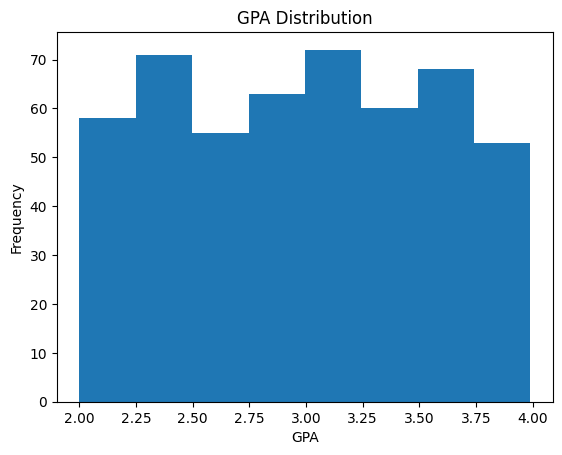

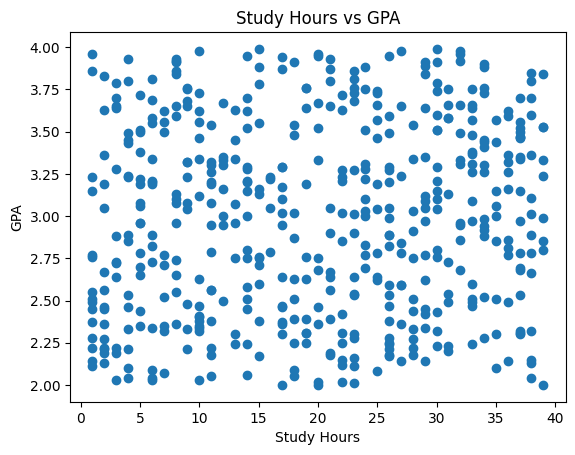

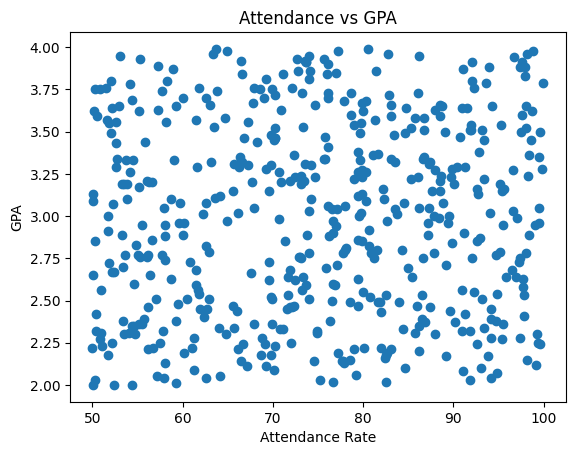


=== CORRELATION MATRIX ===


,StudentID,Age,StudyHoursPerWeek,AttendanceRate,GPA
StudentID,1.000000,-0.019205,0.017845,-0.033530,-0.061763
Age,-0.019205,1.000000,-0.015695,0.037364,0.095805
StudyHoursPerWeek,0.017845,-0.015695,1.000000,0.095716,0.091700
AttendanceRate,-0.033530,0.037364,0.095716,1.000000,0.060828
GPA,-0.061763,0.095805,0.091700,0.060828,1.000000


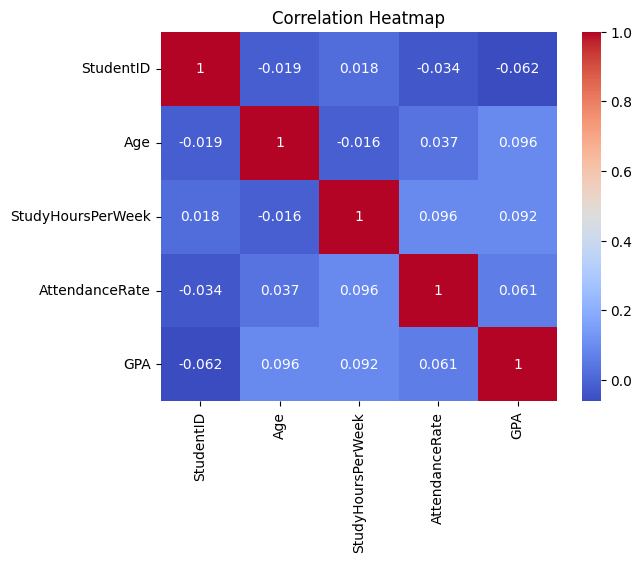

In [2]:
# -------------------- IMPORT REQUIRED LIBRARIES --------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML


# -------------------- LOAD DATASET --------------------

df = pd.read_csv("student_performance_data.csv")


# =====================================================
# 1. DATA STORAGE WITH HTML DISPLAY
# =====================================================

print("=== DATA PREVIEW ===")
display(HTML(df.head().to_html()))

print("\n=== DATASET DIMENSIONS ===")
dimension_df = pd.DataFrame({
    "Total Rows": [df.shape[0]],
    "Total Columns": [df.shape[1]]
})
display(HTML(dimension_df.to_html(index=False)))

print("\n=== COLUMN INFORMATION ===")
info_table = pd.DataFrame({
    "Column Name": df.columns,
    "Non-Null Values": df.count().values,
    "Data Type": df.dtypes.values
})
display(HTML(info_table.to_html(index=False)))

# Save backup file
backup_name = "student_data_backup.csv"
df.to_csv(backup_name, index=False)

print("\nBackup file created successfully.")


# =====================================================
# 2. DATA INTEGRATION
# =====================================================

# Split dataset into two logical parts
academic_df = df[["StudentID", "GPA", "Major"]]
activity_df = df[["StudentID", "ExtraCurricularActivities", "PartTimeJob"]]

print("\n=== ACADEMIC DATA ===")
display(HTML(academic_df.head().to_html()))

print("\n=== ACTIVITY DATA ===")
display(HTML(activity_df.head().to_html()))

# Merge datasets
merged_df = pd.merge(academic_df, activity_df, on="StudentID")

print("\n=== INTEGRATED DATASET ===")
display(HTML(merged_df.head().to_html()))


# =====================================================
# 3. PATTERN DISCOVERY
# =====================================================

print("\n=== STATISTICAL SUMMARY ===")
display(HTML(df.describe().to_html()))

# GPA Distribution
plt.figure()
plt.hist(df["GPA"], bins=8)
plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

# Study Hours vs GPA
plt.figure()
plt.scatter(df["StudyHoursPerWeek"], df["GPA"])
plt.title("Study Hours vs GPA")
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.show()

# Attendance vs GPA
plt.figure()
plt.scatter(df["AttendanceRate"], df["GPA"])
plt.title("Attendance vs GPA")
plt.xlabel("Attendance Rate")
plt.ylabel("GPA")
plt.show()

# Correlation Analysis
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

print("\n=== CORRELATION MATRIX ===")
display(HTML(corr_matrix.to_html()))

# Heatmap
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()